# 11.4. 헬륨 원자의 근사

In [1]:
import sympy as sp

Z, r, r1, r2 = sp.symbols("Z r r_1 r_2", positive=True)

phi_1 = sp.sqrt(Z**3 / sp.pi) * sp.exp(-Z * r1)
phi_2 = sp.sqrt(Z**3 / sp.pi) * sp.exp(-Z * r2)

integral1 = sp.integrate(phi_1.conjugate() * phi_1 * 4 * sp.pi * r1**2, (r1, 0, sp.oo))
integral2 = sp.integrate(phi_2.conjugate() * phi_2 * 4 * sp.pi * r2**2, (r2, 0, sp.oo))
print("규격화 확인:", integral1 * integral2)

규격화 확인: 1


In [2]:
integral3 = sp.integrate(phi_1 * phi_1 / r1 * 4 * sp.pi * r1**2, (r1, 0, sp.oo))
integral4 = sp.integrate(phi_2 * phi_2 / r2 * 4 * sp.pi * r2**2, (r2, 0, sp.oo))
print("첫 번째 적분값: ", integral3 * integral2)
print("두 번째 적분값: ", integral4 * integral1)

첫 번째 적분값:  Z
두 번째 적분값:  Z


In [3]:
f = (4 * sp.pi) ** 2 * phi_1**2 * phi_2**2 * r1**2 * r2**2
case_1 = sp.integrate(f / r1, (r2, 0, r1))
case_2 = sp.integrate(f / r2, (r2, r1, sp.oo))
integral5 = sp.integrate(sp.simplify(case_1 + case_2), (r1, 0, sp.oo))
print("세 번째 적분값: ", integral5)

세 번째 적분값:  5*Z/8


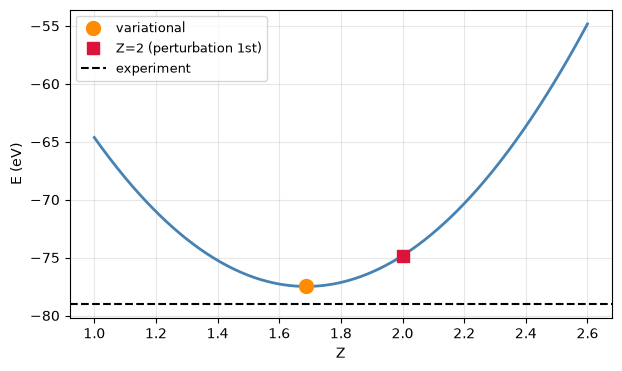

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Eh = 27.2114
E = lambda Z: (Z**2 - 27 / 8 * Z) * Eh
Zs = np.linspace(1.0, 2.6, 450)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Zs, E(Zs), lw=2, color="steelblue")
ax.plot(27 / 16, E(27 / 16), "o", ms=10, color="darkorange", label=f"variational")
ax.plot(2.0, E(2.0), "s", ms=9, color="crimson", label="Z=2 (perturbation 1st)")
ax.axhline(-79.00, color="black", ls="--", lw=1.5, label="experiment")
ax.set_xlabel("Z")
ax.set_ylabel("E (eV)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()